# Watershed Restoration Priority

Map raster change patterns and identify high-priority watershed restoration cells.

This OpenGeoLab case is self-contained: all inputs live in `data/`, and outputs are written to `outputs/`.

Inspired by watershed screening and DEM analysis notebook examples.

In [1]:
import os
os.environ.setdefault("PROJ_DATA", "/opt/conda/share/proj")
os.environ.setdefault("PROJ_LIB", "/opt/conda/share/proj")
from pathlib import Path
import numpy as np
import rasterio
import xarray as xr
import matplotlib.pyplot as plt
from IPython.display import display

DATA = Path('data')
OUT = Path('outputs')
OUT.mkdir(exist_ok=True)
with rasterio.open(DATA / 'surface_a.tif') as src:
    a = src.read(1, masked=True)
    profile = src.profile
with rasterio.open(DATA / 'surface_b.tif') as src:
    b = src.read(1, masked=True)
print({'shape': a.shape, 'crs': profile['crs'].to_string(), 'resolution': profile['transform'][0]})


{'shape': (72, 72), 'crs': 'EPSG:4326', 'resolution': 0.0025}


In [2]:
change = b - a
risk = np.where(change > np.nanpercentile(change, 75), 2, np.where(change < np.nanpercentile(change, 25), 0, 1))
ds = xr.Dataset({
    'baseline': (('y', 'x'), np.asarray(a)),
    'current': (('y', 'x'), np.asarray(b)),
    'change': (('y', 'x'), np.asarray(change)),
    'risk_class': (('y', 'x'), risk),
})
display(ds)
print(ds[['baseline', 'current', 'change']].to_array().mean(dim=('y', 'x')).to_pandas())


/opt/conda/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


<xarray.Dataset> Size: 104kB
Dimensions:     (y: 72, x: 72)
Dimensions without coordinates: y, x
Data variables:
    baseline    (y, x) float32 21kB 0.7251 0.6372 0.6432 ... 1.216 0.7816 0.8489
    current     (y, x) float32 21kB 0.5813 0.6645 0.4322 ... 0.8728 1.008 0.5935
    change      (y, x) float32 21kB -0.1438 0.02735 -0.211 ... 0.2265 -0.2553
    risk_class  (y, x) int64 41kB 0 1 0 1 1 0 2 1 1 0 1 ... 0 0 2 1 2 1 1 0 2 0

variable
baseline    0.512256
current     0.510552
change     -0.001704
dtype: float32


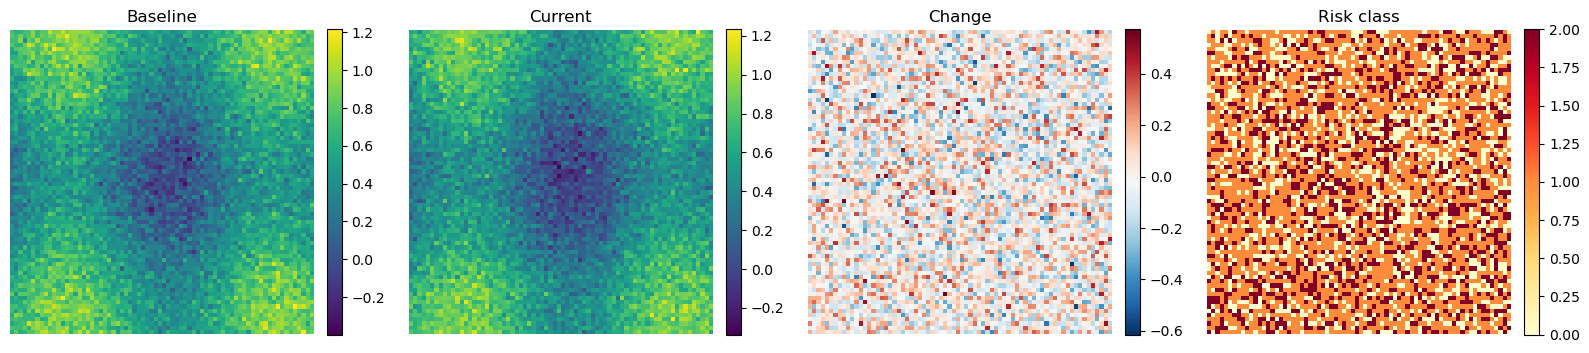

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, data, title, cmap in zip(axes, [a, b, change, risk], ['Baseline', 'Current', 'Change', 'Risk class'], ['viridis', 'viridis', 'RdBu_r', 'YlOrRd']):
    im = ax.imshow(data, cmap=cmap)
    ax.set_title(title)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(OUT / 'raster_change_panel.png', dpi=160)
plt.show()


In [4]:
summary = {
    'mean_change': float(np.nanmean(change)),
    'high_risk_cells': int((risk == 2).sum()),
    'low_risk_cells': int((risk == 0).sum()),
}
print(summary)


{'mean_change': -0.0017040267121046782, 'high_risk_cells': 1296, 'low_risk_cells': 1296}
